In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
df = pd.read_csv("/content/Sample - Superstore.csv", encoding="latin1")
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
#Checking if there is any null values present in the dataset.
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [7]:
df[["Sales", "Quantity", "Discount", "Profit"]].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


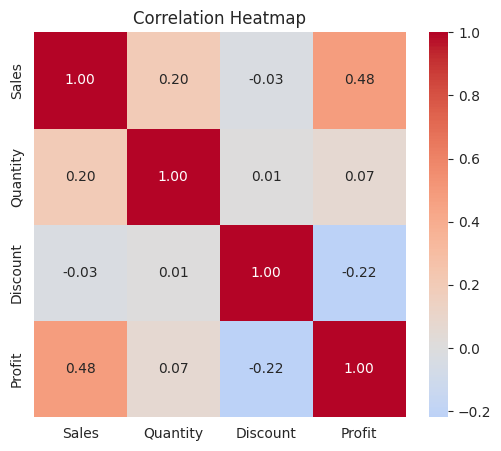

In [8]:
corr = df[["Sales", "Quantity", "Discount", "Profit"]].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

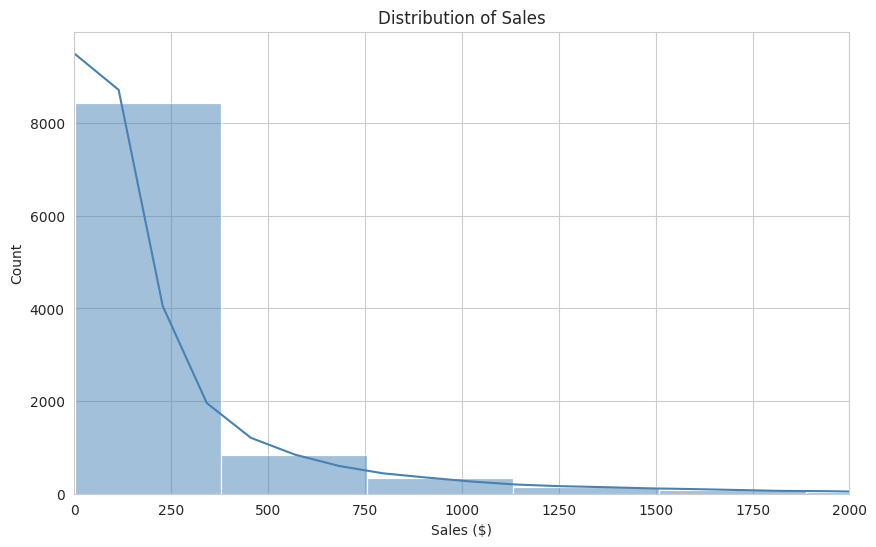

In [9]:
plt.figure(figsize=(10,6))
sns.histplot(df["Sales"], bins=60, kde=True, color="steelblue")
plt.xlim(0, 2000)
plt.title("Distribution of Sales")
plt.xlabel("Sales ($)")
plt.show()

/tmp/ipykernel_1649/2947835414.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Category", y="Profit", palette="Set2")


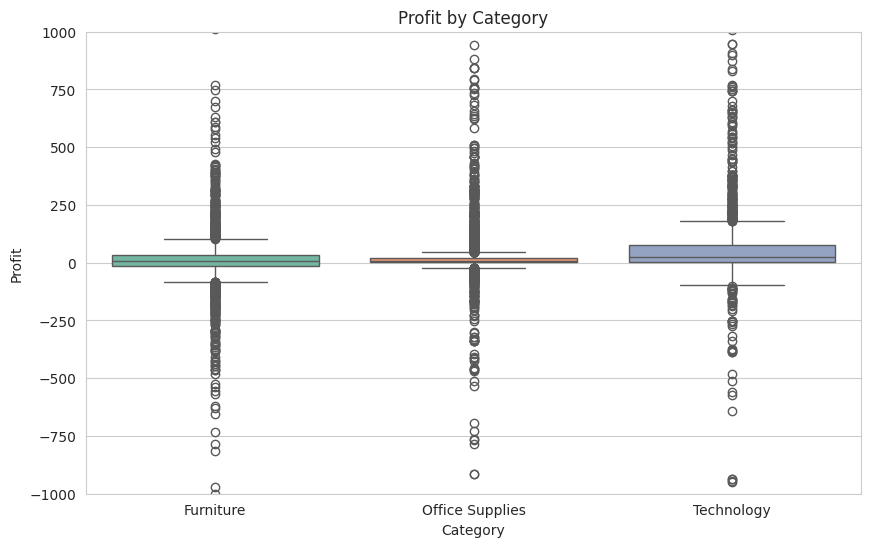

In [10]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Category", y="Profit", palette="Set2")
plt.ylim(-1000, 1000)
plt.title("Profit by Category")
plt.show()

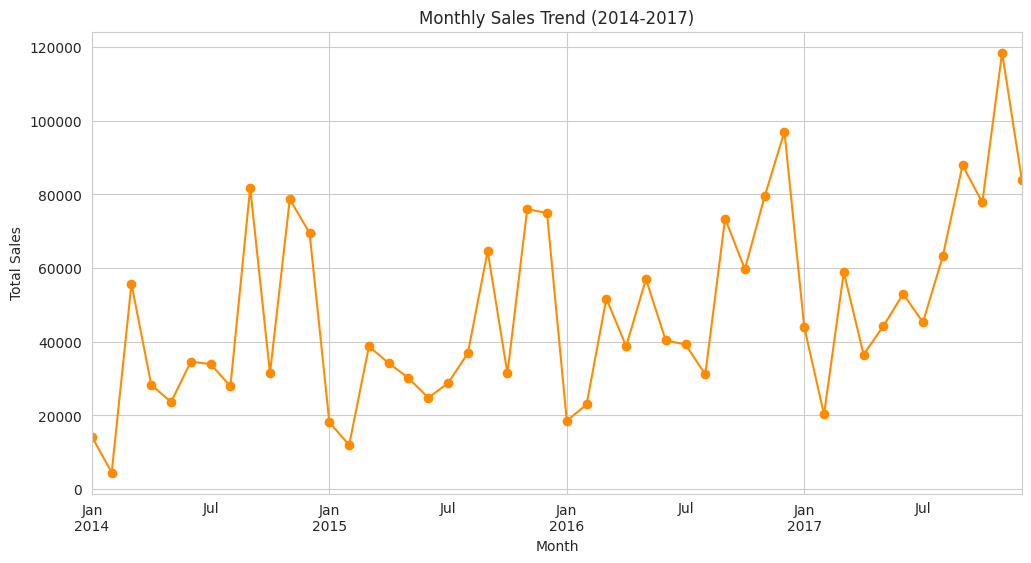

In [13]:
monthly_sales = df.set_index("Order Date").resample("ME")["Sales"].sum()
plt.figure(figsize=(12,6))
monthly_sales.plot(marker="o", color="darkorange")
plt.title("Monthly Sales Trend (2014-2017)")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

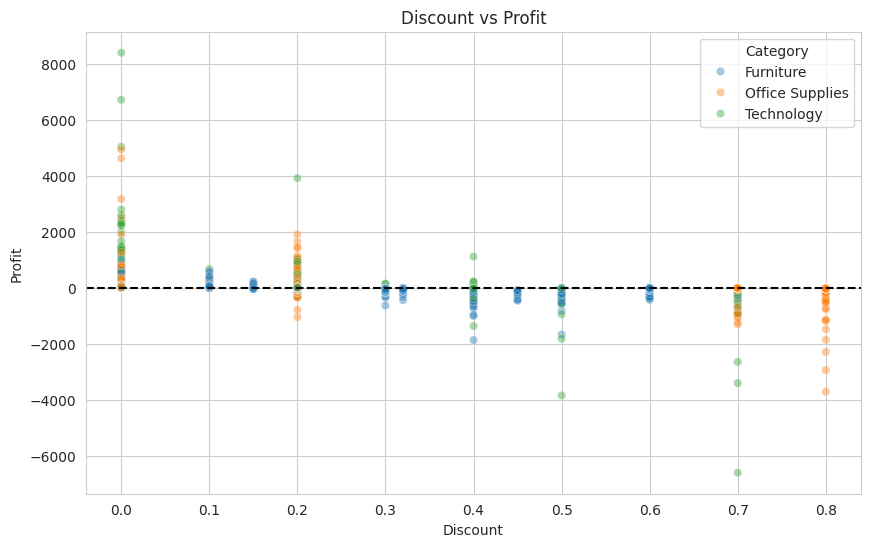

In [12]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Discount", y="Profit", alpha=0.4, hue="Category")
plt.axhline(0, color="black", linestyle="--")
plt.title("Discount vs Profit")
plt.show()

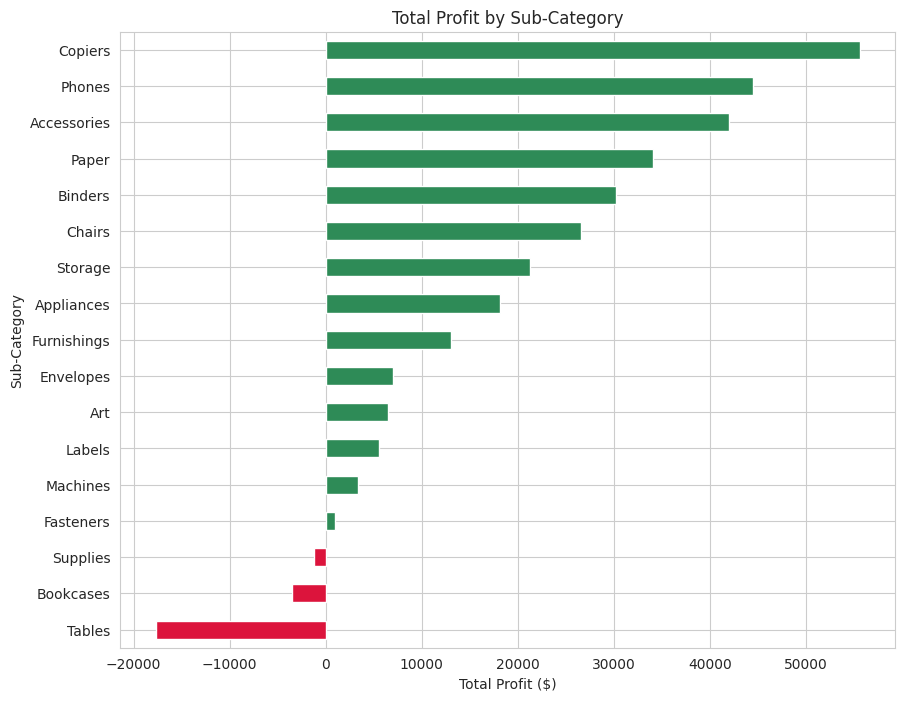

In [14]:
subcat_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values()
plt.figure(figsize=(10,8))
colors = ["crimson" if v < 0 else "seagreen" for v in subcat_profit.values]
subcat_profit.plot(kind="barh", color=colors)
plt.title("Total Profit by Sub-Category")
plt.xlabel("Total Profit ($)")
plt.show()

1. Orders with a discount above 30-40% almost always turn into a loss **(Discount-Profit correlation = -0.22)**
2. The **"Tables" sub-category is the biggest loss-maker**(~$17,725 in losses), making the overall Furniture category weak
3. Sales are seasonal — **peaking in November-December** — and the values are heavily right-skewed (most orders are small, but a few large orders drive most of the total revenue)